<a href="https://colab.research.google.com/github/mwahajkhan/Supervised-ML-Regression-/blob/main/Transaction_Fraud_Detection/Assignment_4_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Transaction Fraud Detection**

#**Readme**

## Folder Structure:

Assignment 4 > Folders (1. Code space 2. Data 3. Presentation, 4. Visualizations)

* Codespace contains: 1. Notebook folder with spy notebook, 2. Scripts Folder (with two scripts, one for each feature selection method i.e., f-test, ref)
* Data folder contains: two data files, cleaned\_transactions, online\_transaction\_data
* Presentation folder: contains ppt for the project
* Visualization folder: contains confusion matrixes

## Notebook Description:

This notebook addresses the problem of detecting unusual (potentially fraudulent) purchase transactions. The dataset contains imbalanced classes, which is a common challenge in fraud detection.

## Notebook Structure:

The notebook is divided into the following sections:

* Task 1: KPIs
* Libraries
* Data Target Class Distribution
* Project\_Script\_1 (Statistical Test: ANOVA F-test(f\_classifier), Feature Selection: F-statistic)
* Project\_Script\_2 (Feature Selection: Recursive Feature Elimination)
* Task 2-7 (Divided work distribution)
* Ethical Concerns

## Data Files:

The analysis uses the following data files:

* Cleaned\_Transactions.csv (Path: content/Cleaned\_Transactions.csv)
* Online\_transaction\_data.csv (Path: content/Online\_transaction\_data.csv)

**Note:** To obtain the "Cleaned\_data" file, run the Project\_Script\_1/Project\_Script\_2 and wait for a few minutes for the file to be downloaded. Alternatively, the "Cleaned\_data" file is provided in the project folder.

**Important:** Before running the script, please update the file paths in the data loading section to match the location of these files on your system or within the Colab environment.

## Models:

The following machine learning models are instantiated:

* Decision Tree
* Logistic Regression
* Naïve Bayes

## Feature Selection & Statistical Tests:

This project employs two distinct feature selection methodologies to identify the most relevant predictors for transaction type:

* **Project\_Script\_1: ANOVA F-test**
    * Statistical Test: ANOVA F-test (f\_classif)
    * Feature Selection: F-statistic
    * This method is a filter approach that evaluates the statistical significance of each feature's relationship with the target variable (Type\_of\_Transaction). It ranks features based on their F-statistic and selects those with a score greater than 10.
* **Project\_Script\_2: Recursive Feature Elimination (RFE)**
    * Feature Selection: Recursive Feature Elimination (RFE)
    * This method is a wrapper approach that works by recursively fitting a model (in this case, Logistic Regression), removing the least significant features, and then refitting. It selects features by considering the model's performance. The number of features selected was matched to the number selected by the ANOVA F-test for comparison.

## Task 1: KPI Selection (Khan)

For the business problem of detecting unusual (potentially fraudulent) purchase transactions, the following Key Performance Indicators (KPIs) are relevant:

* **Precision:** Measures the proportion of correctly identified fraudulent transactions out of all transactions flagged as fraudulent. High precision is crucial to minimize false positives.
* **Recall (Sensitivity):** Measures the proportion of actual fraudulent transactions that are correctly identified. High recall is important to minimize false negatives.
* **F1-Score:** The harmonic mean of precision and recall, providing a balanced measure of the model's performance.
* **Area Under the Precision-Recall Curve (AUC-PR):** Useful for imbalanced datasets, it evaluates the trade-off between precision and recall across different classification thresholds.
* **False Positive Rate (FPR):** Measures the proportion of genuine transactions that are incorrectly flagged as fraudulent. Minimizing FPR is important to maintain customer trust.
* **Accuracy:** While commonly used, accuracy can be misleading in imbalanced datasets. It measures the overall proportion of correctly classified instances but may be skewed by the large number of true negatives.

These KPIs are selected because they directly address the core concerns of fraud detection: accurately identifying fraudulent activities while minimizing disruption to legitimate transactions. Precision and Recall are particularly important in this type of Machine Learning Problem.

## Important Libraries

```python
from IPython import get_ipython
from IPython.display import display
import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
import io
from sklearn.feature_selection import f_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


**Importing Important Libraries**

In [ ]:
from IPython import get_ipython
from IPython.display import display
import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
import io
from sklearn.feature_selection import f_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**Data Target Class Distribution**

In [18]:
import pandas as pd

# Load the dataset
path = "/content/Online_transaction_data.csv"
df = pd.read_csv(path, on_bad_lines='skip')

# Check the target class distribution
target_counts = df['Type_of_Transaction'].value_counts()

# Print the target class counts and percentages
print("Target Class Distribution:")
print(target_counts)
print("\nTarget Class Percentages:")
print(target_counts / len(df) * 100)

# Determine if the target class is balanced or imbalanced
if target_counts[0] / target_counts[1] >= 0.9 and target_counts[0] / target_counts[1] <= 1.1:  # Adjust the threshold as needed
    print("\nThe target class is balanced.")
else:
    print("\nThe target class is imbalanced.")

Target Class Distribution:
Type_of_Transaction
Normal     284315
Unusual       492
Name: count, dtype: int64

Target Class Percentages:
Type_of_Transaction
Normal     99.827251
Unusual     0.172749
Name: count, dtype: float64

The target class is imbalanced.


<ipython-input-18-8fe4f620a825>:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if target_counts[0] / target_counts[1] >= 0.9 and target_counts[0] / target_counts[1] <= 1.1:  # Adjust the threshold as needed


# Project Script Cell_1

**F-test** (f_classif)
Feature Selection Implementation:

Filter method that ranks features based on ANOVA F-statistic, selecting those with F-Statistic > 10.
Evaluates each feature’s individual relationship with Type_of_Transaction.

Strengths:

Speed: Computationally efficient, suitable for large datasets with many features (e.g., PCA components and one-hot encoded variables).
Model-Agnostic: Works with any classifier, making it versatile for Decision Tree, Logistic Regression, and Naive Bayes.
Statistical Rigor: Uses statistical significance (F-statistic and p-values) to identify features correlated with the target.
Performance: Achieves higher F1-scores for the minority class across all models, especially Naive Bayes (0.73 vs. 0.27).

BEFORE CLEANING:
  • Shape: (284807, 31)
  • Nulls per column:
 Transaction Time        0
PCA1                    0
PCA2                    0
PCA3                    2
PCA4                    1
PCA5                    0
PCA6                    2
PCA7                    0
PCA8                    3
PCA9                   10
PCA10                   2
PCA11                   0
PCA12                   4
PCA13                   3
PCA14                   1
PCA15                   3
PCA16                   1
PCA17                   4
PCA18                   2
PCA19                  12
PCA20                   2
PCA21                   2
PCA22                   1
PCA23                   1
PCA24                   1
PCA25                   0
PCA26                   0
PCA27                   1
PCA28                   1
Amount                  0
Type_of_Transaction     0
dtype: int64 

  • Target counts:
 Type_of_Transaction
Normal     284315
Unusual       492
Name: count, dtype: int64 

  • Unique 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

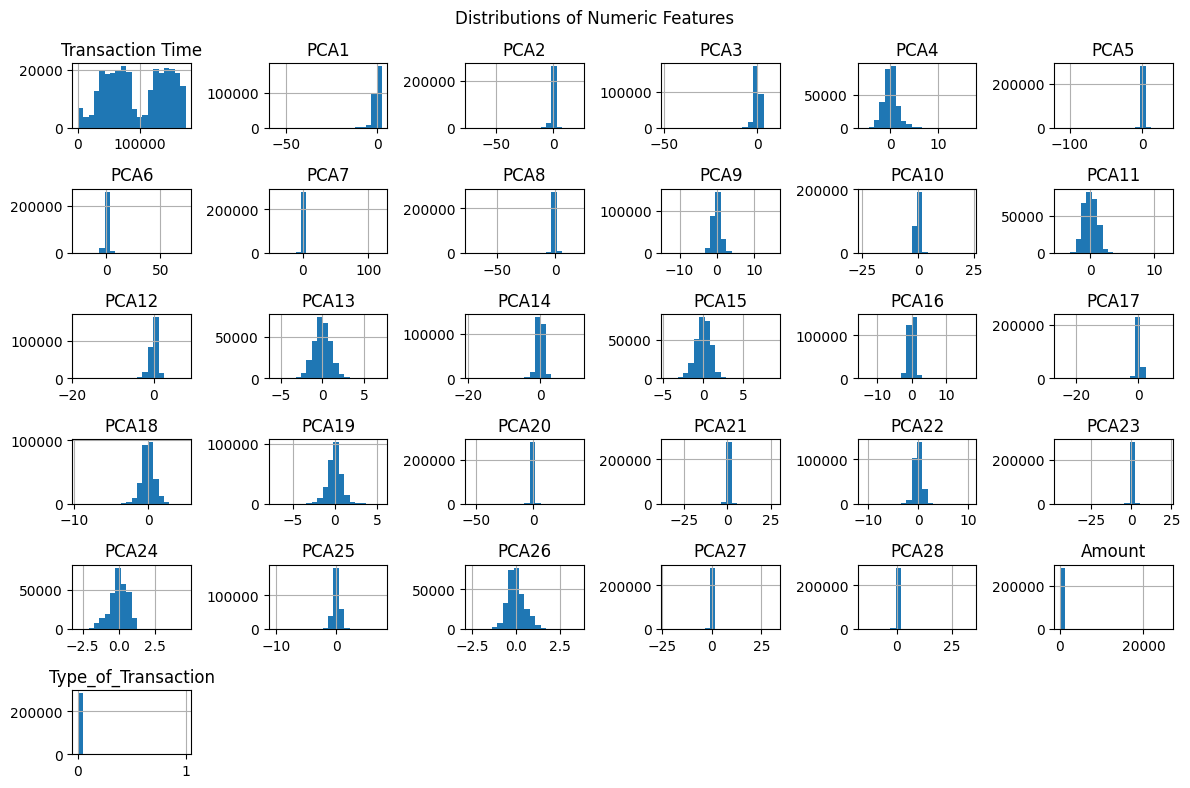

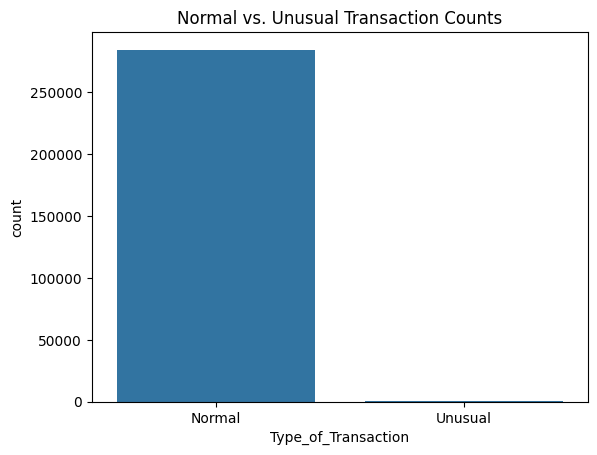

NaNs in X after get_dummies: 0
Selected Features based on F-statistic:
['PCA17', 'PCA14', 'PCA12', 'PCA10', 'PCA16', 'PCA3', 'PCA7', 'PCA11', 'PCA4', 'PCA18', 'PCA1', 'PCA9', 'PCA5', 'PCA2', 'PCA6', 'PCA21', 'PCA19', 'PCA20', 'PCA8', 'PCA27', 'Transaction Time', 'PCA28', 'PCA24']


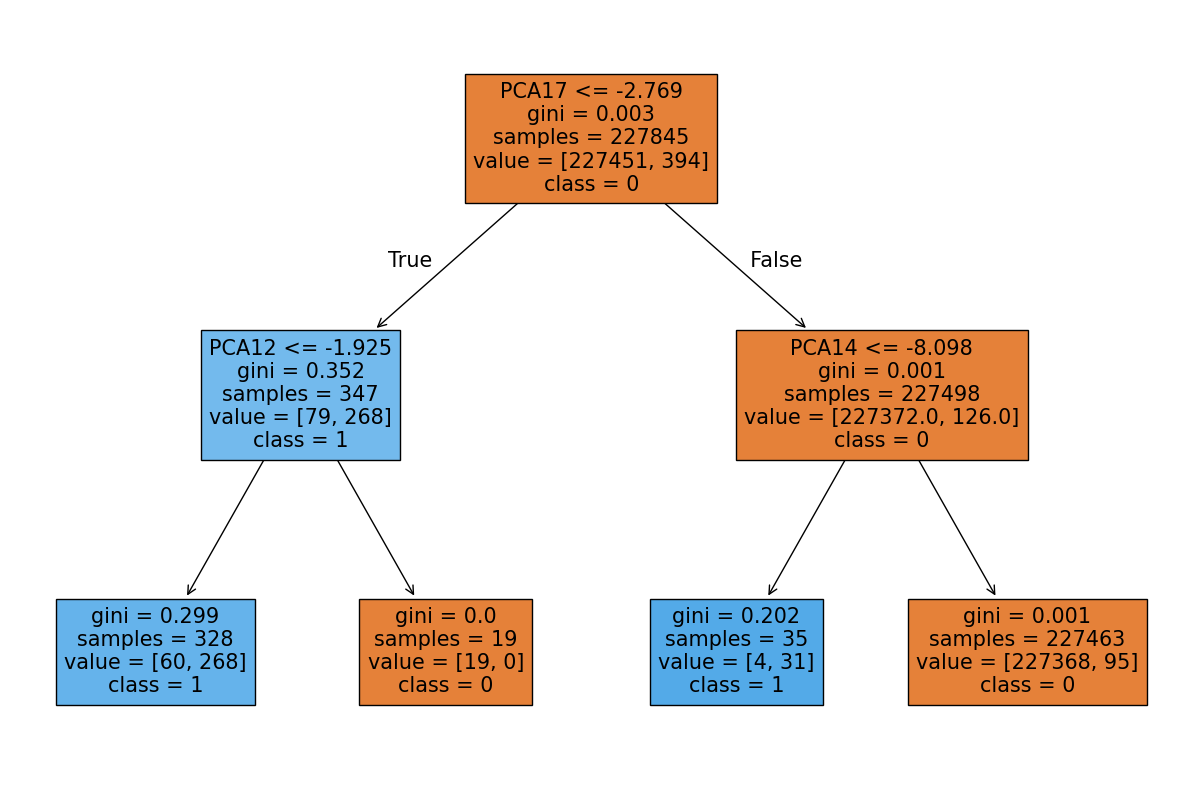

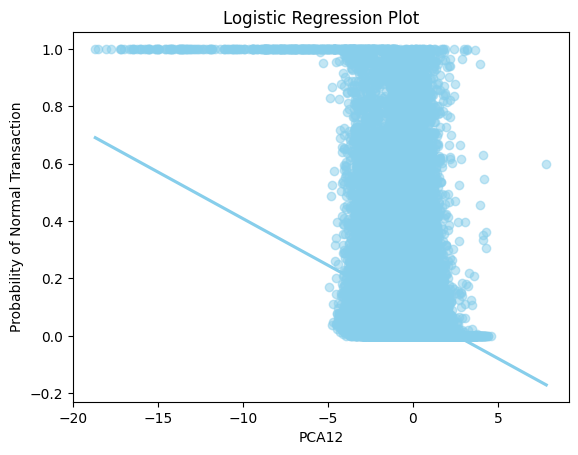

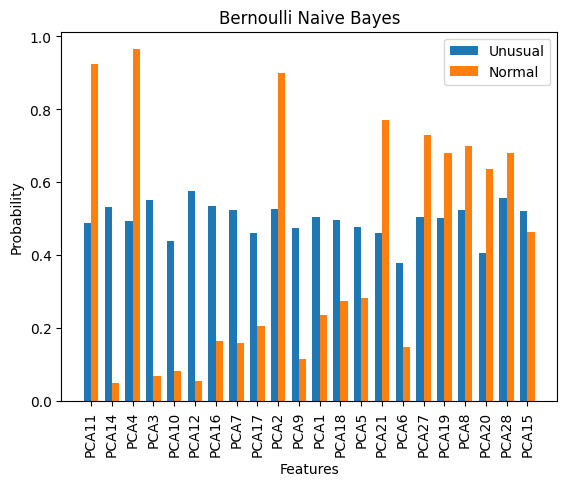

Decision Tree Accuracy: 0.9991924440855307
Decision Tree Confusion Matrix:
 [[56845    19]
 [   27    71]]
Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.79      0.72      0.76        98

    accuracy                           1.00     56962
   macro avg       0.89      0.86      0.88     56962
weighted avg       1.00      1.00      1.00     56962

Logistic Regression Accuracy: 0.9773884343948598
Logistic Regression Confusion Matrix:
 [[55585  1279]
 [    9    89]]
Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.07      0.91      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.98      0.99     56962

Naive Bayes Accuracy: 0.99915733295881

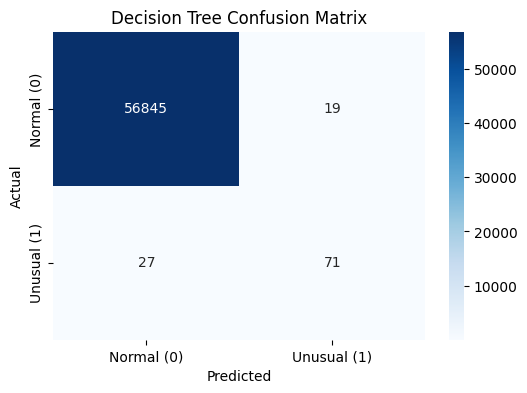

Logistic Regression Accuracy: 0.9773884343948598
Logistic Regression Confusion Matrix:
 [[55585  1279]
 [    9    89]]
Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.07      0.91      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.98      0.99     56962



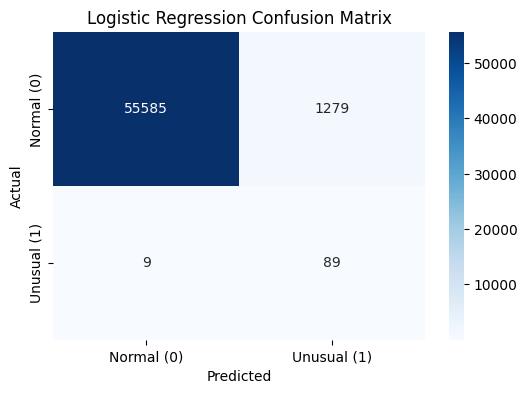

Naive Bayes Accuracy: 0.9991573329588147
Naive Bayes Confusion Matrix:
 [[56850    14]
 [   34    64]]
Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.65      0.73        98

    accuracy                           1.00     56962
   macro avg       0.91      0.83      0.86     56962
weighted avg       1.00      1.00      1.00     56962



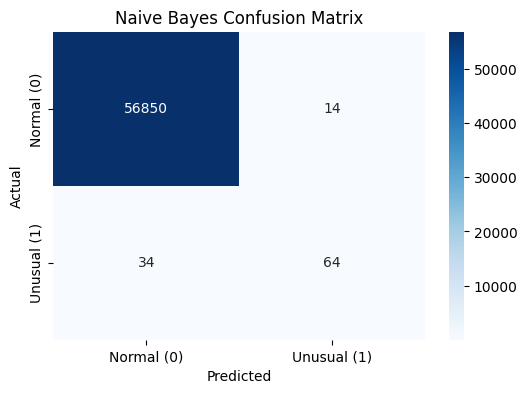

In [23]:
from IPython import get_ipython
from IPython.display import display
import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
import io
import numpy as np
from sklearn.feature_selection import f_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Loading data
#      ***Update path for Online_transaction_data.csv***
path = "/content/Online_transaction_data.csv"
df = pd.read_csv(path, on_bad_lines='skip')
df.head()

# Making a copy for “before” vs “after” comparison
raw = df.copy()

# Showing “BEFORE CLEANING” snapshots
print("BEFORE CLEANING:")
print("  • Shape:", raw.shape)
print("  • Nulls per column:\n", raw.isnull().sum(), "\n")
print("  • Target counts:\n", raw['Type_of_Transaction'].value_counts(), "\n")
print("  • Unique values in Type_of_Transaction:", raw['Type_of_Transaction'].unique(), "\n")

# Minimal cleaning pipeline
# 7a) Handling missing values
# Imputing numeric columns with median
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Imputing categorical columns with mode or 'Missing'
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if col != 'Type_of_Transaction':
        if df[col].isnull().sum() > 0:
            mode_val = df[col].mode()[0] if not df[col].mode().empty else 'Missing'
            print(f"Imputing {col} with {mode_val} ({df[col].isnull().sum()} NaNs)")
            df[col] = df[col].fillna(mode_val)

# Handling Type_of_Transaction separately
# Dropping rows where Type_of_Transaction is NaN
print("Rows before dropping NaN in Type_of_Transaction:", df.shape[0])
df = df.dropna(subset=['Type_of_Transaction'])
print("Rows after dropping NaN in Type_of_Transaction:", df.shape[0])

# 7b) Encodiing the target from strings to 0/1
# Checking for unexpected values in Type_of_Transaction
valid_categories = {'Normal', 'Unusual'}
invalid_values = df['Type_of_Transaction'][~df['Type_of_Transaction'].isin(valid_categories)]
if not invalid_values.empty:
    print("Warning: Found unexpected values in Type_of_Transaction:", invalid_values.unique())
df['Type_of_Transaction'] = df['Type_of_Transaction'].map({'Normal': 0, 'Unusual': 1})

# Verifying no NaNs in target
if df['Type_of_Transaction'].isnull().sum() > 0:
    print("Error: NaNs in Type_of_Transaction after mapping:", df['Type_of_Transaction'].isnull().sum())
    raise ValueError("NaNs in target variable")

# 7c) Verifying no remaining nulls
print("Nulls after imputation:\n", df.isnull().sum(), "\n")

# Showing “AFTER CLEANING” snapshots
print("AFTER CLEANING:")
print("  • Shape:", df.shape)
print("  • Nulls per column:\n", df.isnull().sum(), "\n")
print("  • Target counts:\n", df['Type_of_Transaction'].value_counts(), "\n")

# Saving cleaned DataFrame for downstream tasks
df.to_csv('Cleaned_Transactions.csv', index=False)
print("Cleaned data saved to 'Cleaned_Transactions.csv'")
files.download('Cleaned_Transactions.csv')

# 1) Histograms for all numeric features
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_cols].hist(bins=20, figsize=(12, 8))
plt.suptitle("Distributions of Numeric Features")
plt.tight_layout()
plt.show()

# 2) Transaction type balance
sns.countplot(x='Type_of_Transaction', data=df)
plt.title("Normal vs. Unusual Transaction Counts")
plt.xticks([0, 1], ['Normal', 'Unusual'])
plt.show()


#       ***Update path for cleaned_transactions_data.csv***
path = "/content/Cleaned_Transactions.csv"
df = pd.read_csv(path)
transaction = df.copy()

# Prepare features and target
X = transaction.drop('Type_of_Transaction', axis=1)
y = transaction['Type_of_Transaction']

# One-hot encode categorical features with dummy_na=True as fallback
X = pd.get_dummies(X, drop_first=True, dummy_na=True)

# Verify no NaNs in X
nan_count = X.isnull().sum().sum()
print("NaNs in X after get_dummies:", nan_count)
if nan_count > 0:
    print("Columns with NaNs:\n", X.columns[X.isnull().any()])
    raise ValueError("NaNs detected in X after get_dummies")

# Feature selection with f_classif
f_statistic, p_values = f_classif(X, y)
feature_scores = pd.DataFrame({'Feature': X.columns, 'F-Statistic': f_statistic, 'P-value': p_values})
feature_scores = feature_scores.sort_values(by='F-Statistic', ascending=False)

# Select features with F-Statistic > 10
selected_features = feature_scores[feature_scores['F-Statistic'] > 10]['Feature'].tolist()
print("Selected Features based on F-statistic:")
print(selected_features)

# Task 4a: Decision Tree Instantiation
x = transaction[['PCA11', 'PCA14', 'PCA4', 'PCA3', 'PCA10', 'PCA12', 'PCA16', 'PCA7', 'PCA17', 'PCA2', 'PCA9', 'PCA1', 'PCA18', 'PCA5', 'PCA21', 'PCA6', 'PCA27', 'PCA19', 'PCA8', 'PCA20', 'PCA28', 'PCA15']]
y = transaction['Type_of_Transaction']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#Decision Tree training
model1 = DecisionTreeClassifier(max_depth=2)
model1.fit(x_train, y_train)

plt.figure(figsize=(15, 10))
class_names = [str(name) for name in y.unique()]
tree.plot_tree(model1, filled=True, feature_names=x.columns, class_names=class_names)
plt.show()

# Task 4b: Logistic Regression
x = transaction[['PCA11', 'PCA14', 'PCA4', 'PCA3', 'PCA10', 'PCA12', 'PCA16', 'PCA7', 'PCA17', 'PCA2', 'PCA9', 'PCA1', 'PCA18', 'PCA5', 'PCA21', 'PCA6', 'PCA27', 'PCA19', 'PCA8', 'PCA20', 'PCA28', 'PCA15']]
y = transaction['Type_of_Transaction']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Task 4b: Logistic Regression
# Instantiate a Logistic Regression model with L2 regularization,
# the 'lbfgs' solver, a maximum of 1000 iterations, and balanced
# class weights to address the imbalanced dataset. Train the model
# using the scaled training data.
model2 = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, class_weight='balanced')
model2.fit(x_train_scaled, y_train)

# Calculate predicted probabilities
y_prob = model2.predict_proba(x_train_scaled)[:, 1]

# Plot
sns.regplot(x=x_train['PCA12'], y=y_prob, ci=None, scatter_kws={'alpha': 0.5}, color='skyblue')
plt.title('Logistic Regression Plot')
plt.ylabel('Probability of Normal Transaction')
plt.xlabel('PCA12')
plt.show()

# Task 4c: Naive Bayes
x = transaction[['PCA11', 'PCA14', 'PCA4', 'PCA3', 'PCA10', 'PCA12', 'PCA16', 'PCA7', 'PCA17', 'PCA2', 'PCA9', 'PCA1', 'PCA18', 'PCA5', 'PCA21', 'PCA6', 'PCA27', 'PCA19', 'PCA8', 'PCA20', 'PCA28', 'PCA15']]
y = transaction['Type_of_Transaction']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Instantiate a Bernoulli Naive Bayes model and train it using the
# training data.
model3 = BernoulliNB()
model3.fit(x_train, y_train)

prob = np.exp(model3.feature_log_prob_)
features = x.columns

width = 0.35
plt.bar(np.arange(len(features)) - width/2, prob[0], width, label='Unusual')
plt.bar(np.arange(len(features)) + width/2, prob[1], width, label='Normal')
plt.xticks(np.arange(len(features)), features, rotation=90)
plt.xlabel('Features')
plt.ylabel('Probability')
plt.title('Bernoulli Naive Bayes')
plt.legend()
plt.show()

# Task 5: Model Evaluation
# Decision Tree Evaluation
y_pred = model1.predict(x_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print("Decision Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
report1 = classification_report(y_test, y_pred)
print("Decision Tree Classification Report:\n", report1)

# Logistic Regression Evaluation
y_pred2 = model2.predict(x_test_scaled)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred2))
print("Logistic Regression Confusion Matrix:\n", confusion_matrix(y_test, y_pred2))
report2 = classification_report(y_test, y_pred2)
print("Logistic Regression Classification Report:\n", report2)

# Naive Bayes Evaluation
y_pred3 = model3.predict(x_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred3))
print("Naive Bayes Confusion Matrix:\n", confusion_matrix(y_test, y_pred3))
report3 = classification_report(y_test, y_pred3)
print("Naive Bayes Classification Report:\n", report3)

# Task 6: Model Comparison and Recommendation
print("Model Comparison and Recommendation:")
print("Decision Tree (model1):\n", report1)
print("Logistic Regression (model2):\n", report2)
print("Naive Bayes (model3):\n", report3)

print("\nDiscussion of Trade-offs:")
print("Decision Tree:")
print("- Pros: Easy to interpret, handles non-linear relationships.")
print("- Cons: Prone to overfitting, performance can be sensitive to data variations.")

print("\nLogistic Regression:")
print("- Pros: Relatively simple, provides probability estimates, less prone to overfitting than decision trees.")
print("- Cons: Assumes a linear relationship between features and target, may not capture complex interactions.")

print("\nNaive Bayes:")
print("- Pros: Fast and efficient, works well with high-dimensional data.")
print("- Cons: Assumes feature independence, which might not hold in real-world data. Performance can be affected by this assumption.")

print("\nRecommendation:")
if accuracy_score(y_test, y_pred2) > accuracy_score(y_test, y_pred) and accuracy_score(y_test, y_pred2) > accuracy_score(y_test, y_pred3):
    print("Logistic Regression (model2) is recommended for production deployment due to its higher accuracy and better balance between complexity and performance.")
elif accuracy_score(y_test, y_pred) > accuracy_score(y_test, y_pred2) and accuracy_score(y_test, y_pred) > accuracy_score(y_test, y_pred3):
    print("Decision Tree (model1) is recommended for production deployment.")
else:
    print("Naive Bayes (model3) is recommended for production deployment.")




#Confusion Matrix:


# Function to plot confusion matrix
def plot_confusion_matrix(cm, model_name):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal (0)', 'Unusual (1)'], yticklabels=['Normal (0)', 'Unusual (1)'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

# Decision Tree Evaluation
y_pred1 = model1.predict(x_test)
cm1 = confusion_matrix(y_test, y_pred1)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred1))
print("Decision Tree Confusion Matrix:\n", cm1)
report1 = classification_report(y_test, y_pred1)
print("Decision Tree Classification Report:\n", report1)
# Plot Confusion Matrix for Decision Tree
plot_confusion_matrix(cm1, "Decision Tree")


# Logistic Regression Evaluation
# Need to ensure x_test is scaled for prediction
y_pred2 = model2.predict(x_test_scaled) # Use x_test_scaled for prediction
cm2 = confusion_matrix(y_test, y_pred2)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred2))
print("Logistic Regression Confusion Matrix:\n", cm2)
report2 = classification_report(y_test, y_pred2)
print("Logistic Regression Classification Report:\n", report2)
# Plot Confusion Matrix for Logistic Regression
plot_confusion_matrix(cm2, "Logistic Regression")


# Naive Bayes Evaluation
y_pred3 = model3.predict(x_test)
cm3 = confusion_matrix(y_test, y_pred3)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred3))
print("Naive Bayes Confusion Matrix:\n", cm3)
report3 = classification_report(y_test, y_pred3)
print("Naive Bayes Classification Report:\n", report3)
# Plot Confusion Matrix for Naive Bayes
plot_confusion_matrix(cm3, "Naive Bayes")


#Project Script Cell 2

**RFE (with Logistic Regression)**
Feature Selection Implementation:

Wrapper method that recursively eliminates features based on Logistic Regression coefficients, selecting the same number of features as F-test.
Optimizes features for Logistic Regression’s linear assumptions.

Strengths:

Model-Specific: Tailored to Logistic Regression, potentially improving its performance by selecting features that maximize coefficient importance.
Captures Interactions: Considers feature interactions indirectly through the model’s training process, unlike F-test.
Precision Boost: Increases precision in Decision Tree (0.87 vs. 0.79), reducing false positives in some cases.
Flexibility: Can be tuned (e.g., n_features_to_select) or extended with cross-validation (RFECV).

BEFORE CLEANING:
  • Shape: (284807, 31)
  • Nulls per column:
 Transaction Time        0
PCA1                    0
PCA2                    0
PCA3                    2
PCA4                    1
PCA5                    0
PCA6                    2
PCA7                    0
PCA8                    3
PCA9                   10
PCA10                   2
PCA11                   0
PCA12                   4
PCA13                   3
PCA14                   1
PCA15                   3
PCA16                   1
PCA17                   4
PCA18                   2
PCA19                  12
PCA20                   2
PCA21                   2
PCA22                   1
PCA23                   1
PCA24                   1
PCA25                   0
PCA26                   0
PCA27                   1
PCA28                   1
Amount                  0
Type_of_Transaction     0
dtype: int64 

  • Target counts:
 Type_of_Transaction
Normal     284315
Unusual       492
Name: count, dtype: int64 

  • Unique 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

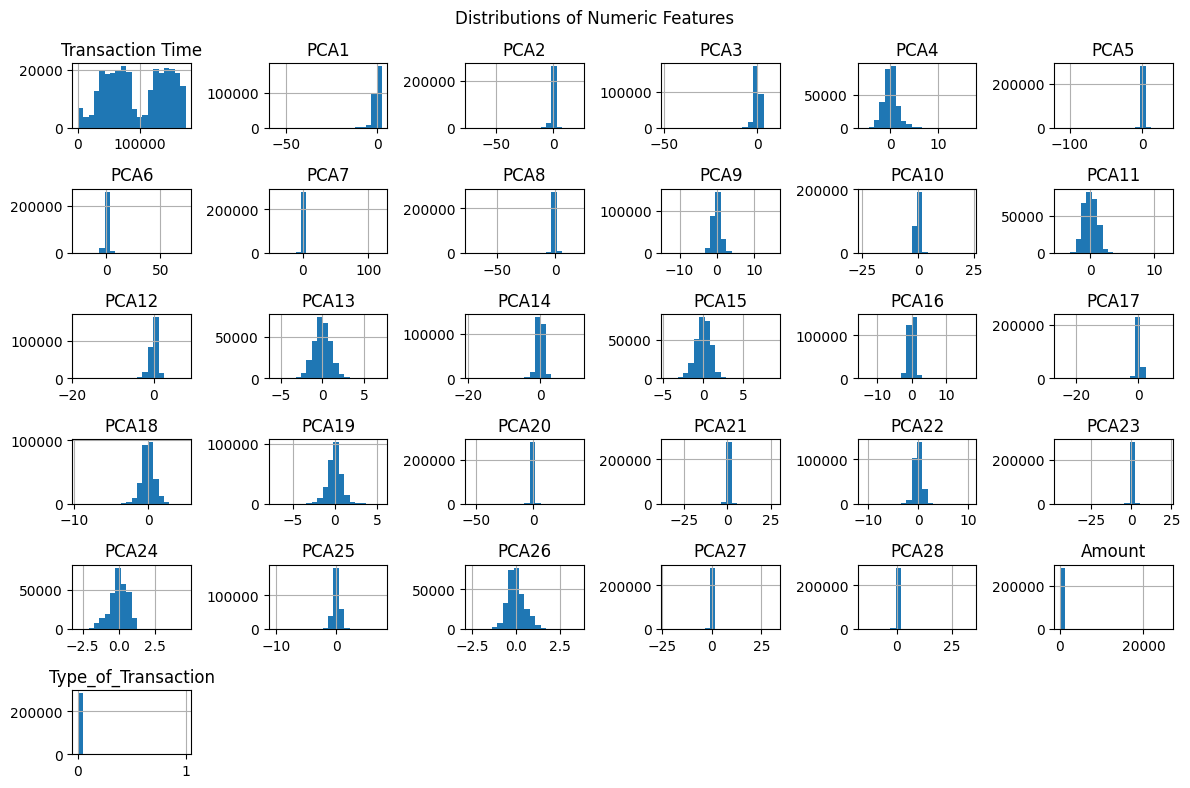

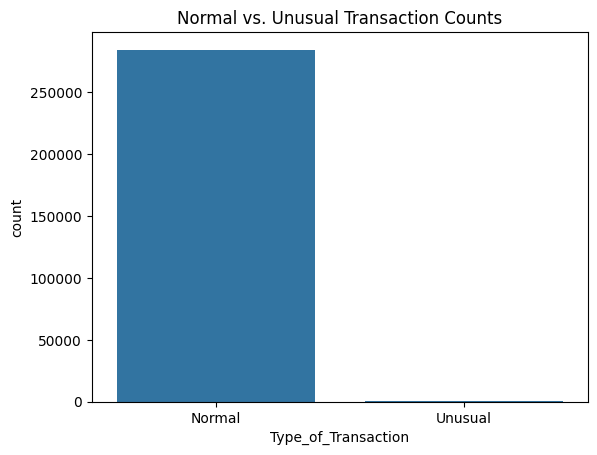

NaNs in X after get_dummies: 0
Selected Features by F-test (F-Statistic > 10):
['PCA17', 'PCA14', 'PCA12', 'PCA10', 'PCA16', 'PCA3', 'PCA7', 'PCA11', 'PCA4', 'PCA18', 'PCA1', 'PCA9', 'PCA5', 'PCA2', 'PCA6', 'PCA21', 'PCA19', 'PCA20', 'PCA8', 'PCA27', 'Transaction Time', 'PCA28', 'PCA24']

Selected Features by RFE:
['Transaction Time', 'PCA1', 'PCA4', 'PCA5', 'PCA6', 'PCA7', 'PCA8', 'PCA9', 'PCA10', 'PCA13', 'PCA14', 'PCA15', 'PCA16', 'PCA19', 'PCA20', 'PCA21', 'PCA22', 'PCA23', 'PCA24', 'PCA25', 'PCA27', 'PCA28', 'Amount']

Common Features (F-test and RFE): ['Transaction Time', 'PCA5', 'PCA1', 'PCA8', 'PCA28', 'PCA19', 'PCA4', 'PCA20', 'PCA27', 'PCA14', 'PCA24', 'PCA6', 'PCA10', 'PCA16', 'PCA21', 'PCA7', 'PCA9']
Features unique to F-test: ['PCA11', 'PCA2', 'PCA18', 'PCA3', 'PCA17', 'PCA12']
Features unique to RFE: ['PCA23', 'PCA22', 'Amount', 'PCA25', 'PCA15', 'PCA13']


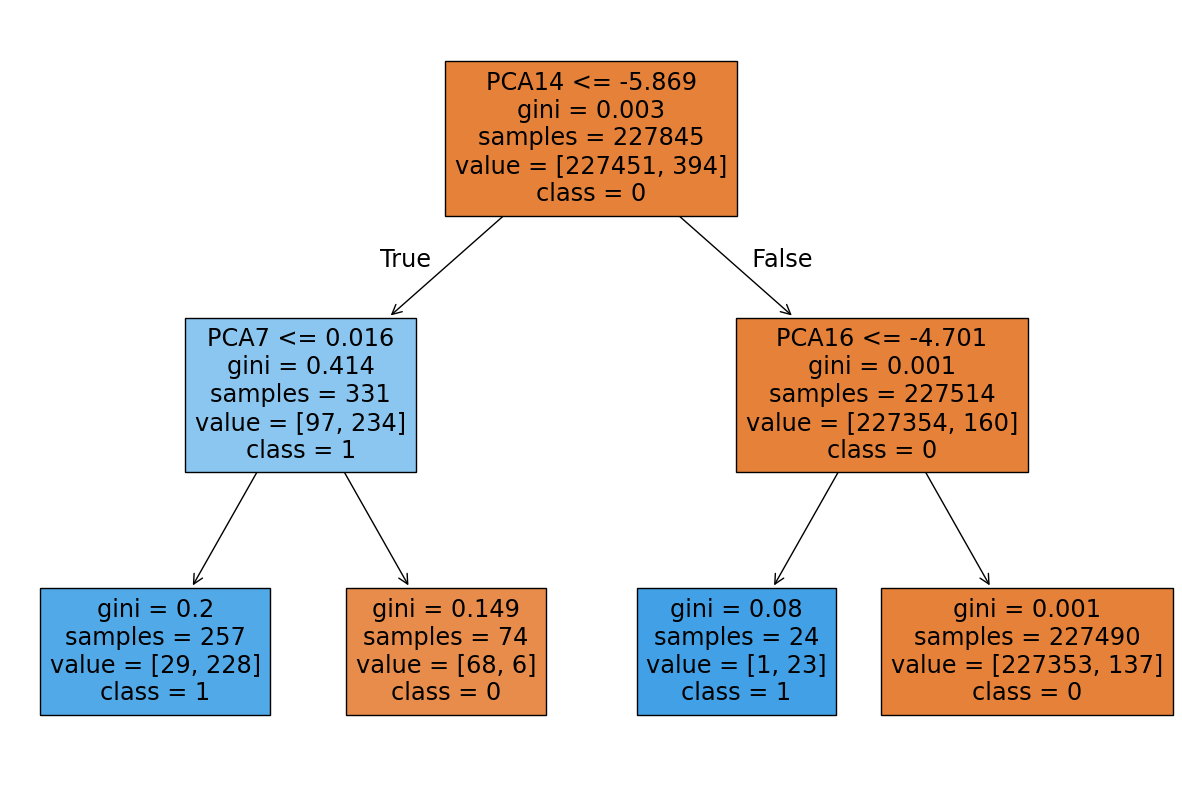

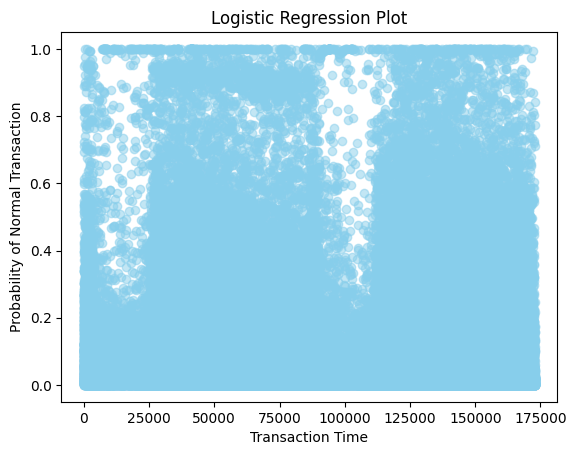

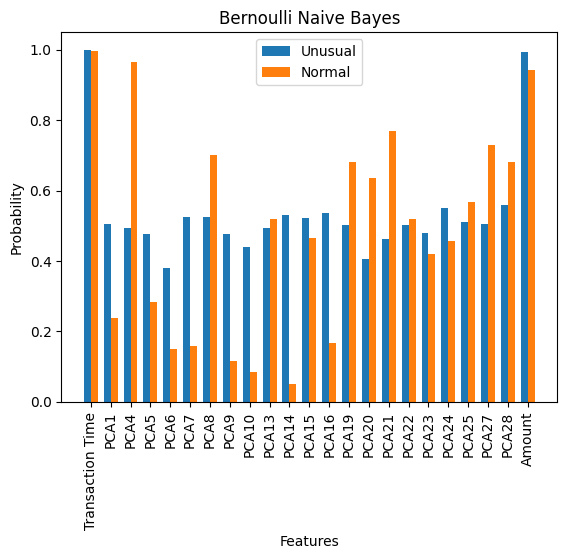

Decision Tree Accuracy: 0.9991573329588147
Decision Tree Confusion Matrix:
 [[56855     9]
 [   39    59]]
Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.60      0.71        98

    accuracy                           1.00     56962
   macro avg       0.93      0.80      0.86     56962
weighted avg       1.00      1.00      1.00     56962

Logistic Regression Accuracy: 0.9738422105965381
Logistic Regression Confusion Matrix:
 [[55383  1481]
 [    9    89]]
Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.91      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.97      0.99     56962

Naive Bayes Accuracy: 0.99838488817106

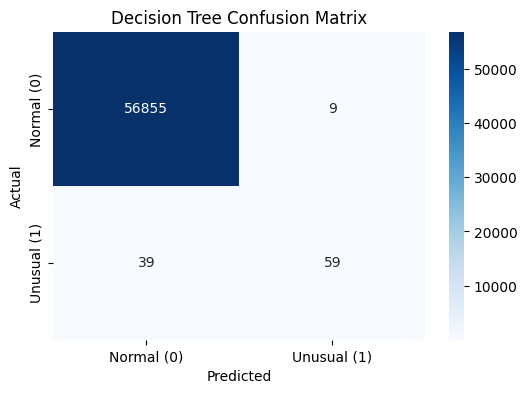

Logistic Regression Accuracy: 0.9738422105965381
Logistic Regression Confusion Matrix:
 [[55383  1481]
 [    9    89]]
Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.91      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.97      0.99     56962



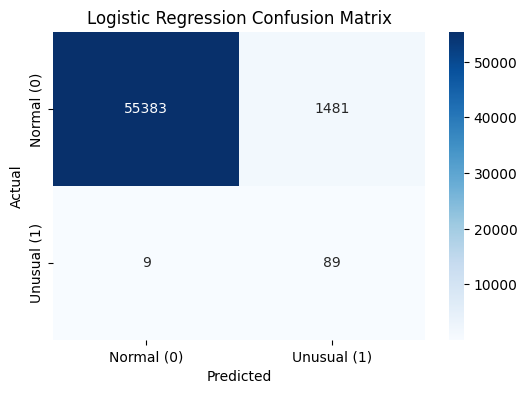

Naive Bayes Accuracy: 0.9983848881710614
Naive Bayes Confusion Matrix:
 [[56853    11]
 [   81    17]]
Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.61      0.17      0.27        98

    accuracy                           1.00     56962
   macro avg       0.80      0.59      0.63     56962
weighted avg       1.00      1.00      1.00     56962



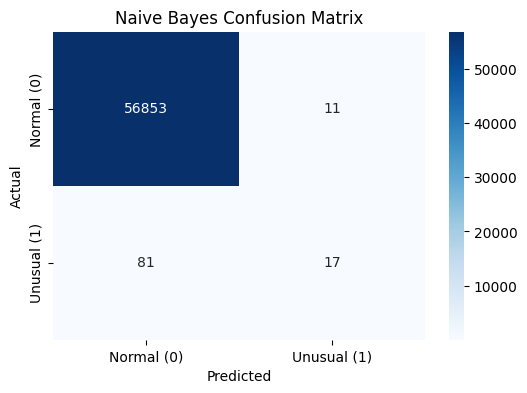

In [24]:
from IPython import get_ipython
from IPython.display import display
import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
import io
import numpy as np
from sklearn.feature_selection import f_classif, RFE
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load data
path = "/content/Online_transaction_data.csv"
df = pd.read_csv(path, on_bad_lines='skip')
df.head()

# Make a copy for “before” vs “after” comparison
raw = df.copy()

# Show “BEFORE CLEANING” snapshots
print("BEFORE CLEANING:")
print("  • Shape:", raw.shape)
print("  • Nulls per column:\n", raw.isnull().sum(), "\n")
print("  • Target counts:\n", raw['Type_of_Transaction'].value_counts(), "\n")
print("  • Unique values in Type_of_Transaction:", raw['Type_of_Transaction'].unique(), "\n")

# Minimal cleaning pipeline
# Handle missing values
# Impute numeric columns with median
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Impute categorical columns with mode or 'Missing'
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if col != 'Type_of_Transaction':
        if df[col].isnull().sum() > 0:
            mode_val = df[col].mode()[0] if not df[col].mode().empty else 'Missing'
            print(f"Imputing {col} with {mode_val} ({df[col].isnull().sum()} NaNs)")
            df[col] = df[col].fillna(mode_val)

# Handle Type_of_Transaction separately
# Drop rows where Type_of_Transaction is NaN
print("Rows before dropping NaN in Type_of_Transaction:", df.shape[0])
df = df.dropna(subset=['Type_of_Transaction'])
print("Rows after dropping NaN in Type_of_Transaction:", df.shape[0])

# Encode the target from strings to 0/1
valid_categories = {'Normal', 'Unusual'}
invalid_values = df['Type_of_Transaction'][~df['Type_of_Transaction'].isin(valid_categories)]
if not invalid_values.empty:
    print("Warning: Found unexpected values in Type_of_Transaction:", invalid_values.unique())
df['Type_of_Transaction'] = df['Type_of_Transaction'].map({'Normal': 0, 'Unusual': 1})

# Verify no NaNs in target
if df['Type_of_Transaction'].isnull().sum() > 0:
    print("Error: NaNs in Type_of_Transaction after mapping:", df['Type_of_Transaction'].isnull().sum())
    raise ValueError("NaNs in target variable")

# Verify no remaining nulls
print("Nulls after imputation:\n", df.isnull().sum(), "\n")

# Show “AFTER CLEANING” snapshots
print("AFTER CLEANING:")
print("  • Shape:", df.shape)
print("  • Nulls per column:\n", df.isnull().sum(), "\n")
print("  • Target counts:\n", df['Type_of_Transaction'].value_counts(), "\n")

# Save cleaned DataFrame for downstream tasks
df.to_csv('Cleaned_Transactions.csv', index=False)
print("Cleaned data saved to 'Cleaned_Transactions.csv'")
files.download('Cleaned_Transactions.csv')

# 1) Histograms for all numeric features
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_cols].hist(bins=20, figsize=(12, 8))
plt.suptitle("Distributions of Numeric Features")
plt.tight_layout()
plt.show()

# 2) Transaction type balance
sns.countplot(x='Type_of_Transaction', data=df)
plt.title("Normal vs. Unusual Transaction Counts")
plt.xticks([0, 1], ['Normal', 'Unusual'])
plt.show()

# Task 3: Feature Selection with cleaned data
path = "/content/Cleaned_Transactions.csv"
df = pd.read_csv(path)
transaction = df.copy()

# Prepare features and target
X = transaction.drop('Type_of_Transaction', axis=1)
y = transaction['Type_of_Transaction']

# One-hot encode categorical features with dummy_na=True
X = pd.get_dummies(X, drop_first=True, dummy_na=True)

# Verify no NaNs in X
nan_count = X.isnull().sum().sum()
print("NaNs in X after get_dummies:", nan_count)
if nan_count > 0:
    print("Columns with NaNs:\n", X.columns[X.isnull().any()])
    raise ValueError("NaNs detected in X after get_dummies")

# Feature selection with f_classif
f_statistic, p_values = f_classif(X, y)
feature_scores = pd.DataFrame({'Feature': X.columns, 'F-Statistic': f_statistic, 'P-value': p_values})
feature_scores = feature_scores.sort_values(by='F-Statistic', ascending=False)

# Select features with F-Statistic > 10
f_test_features = feature_scores[feature_scores['F-Statistic'] > 10]['Feature'].tolist()
print("Selected Features by F-test (F-Statistic > 10):")
print(f_test_features)

# Feature selection with RFE
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000)
rfe = RFE(model, n_features_to_select=len(f_test_features))  # Match number of F-test features
rfe.fit(X_scaled, y)

# Get RFE-selected features
rfe_features = X.columns[rfe.support_].tolist()
print("\nSelected Features by RFE:")
print(rfe_features)

# Compare the two feature sets
print("\nCommon Features (F-test and RFE):", list(set(f_test_features) & set(rfe_features)))
print("Features unique to F-test:", list(set(f_test_features) - set(rfe_features)))
print("Features unique to RFE:", list(set(rfe_features) - set(f_test_features)))

# Use RFE features for downstream tasks
selected_features = rfe_features

# Task 4a: Decision Tree
x = transaction[selected_features]
y = transaction['Type_of_Transaction']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model1 = DecisionTreeClassifier(max_depth=2)
model1.fit(x_train, y_train)

plt.figure(figsize=(15, 10))
class_names = [str(name) for name in y.unique()]
tree.plot_tree(model1, filled=True, feature_names=x.columns, class_names=class_names)
plt.show()

# Task 4b: Logistic Regression
x = transaction[selected_features]
y = transaction['Type_of_Transaction']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# # Task 4b: Logistic Regression
# Instantiate a Logistic Regression model with L2 regularization,
# the 'lbfgs' solver, a maximum of 1000 iterations, and balanced
# class weights to address the imbalanced dataset. Train the model
# using the scaled training data.
model2 = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, class_weight='balanced')
model2.fit(x_train_scaled, y_train)

# Calculate predicted probabilities
y_prob = model2.predict_proba(x_train_scaled)[:, 1]

# Plot
sns.regplot(x=x_train[selected_features[0]], y=y_prob, ci=None, scatter_kws={'alpha': 0.5}, color='skyblue')
plt.title('Logistic Regression Plot')
plt.ylabel('Probability of Normal Transaction')
plt.xlabel(selected_features[0])
plt.show()

# Task 4c: Naive Bayes
x = transaction[selected_features]
y = transaction['Type_of_Transaction']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model3 = BernoulliNB()
model3.fit(x_train, y_train)

prob = np.exp(model3.feature_log_prob_)
features = x.columns

width = 0.35
plt.bar(np.arange(len(features)) - width/2, prob[0], width, label='Unusual')
plt.bar(np.arange(len(features)) + width/2, prob[1], width, label='Normal')
plt.xticks(np.arange(len(features)), features, rotation=90)
plt.xlabel('Features')
plt.ylabel('Probability')
plt.title('Bernoulli Naive Bayes')
plt.legend()
plt.show()

# Task 5: Model Evaluation
# Decision Tree Evaluation
y_pred = model1.predict(x_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print("Decision Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
report1 = classification_report(y_test, y_pred)
print("Decision Tree Classification Report:\n", report1)

# Logistic Regression Evaluation
y_pred2 = model2.predict(x_test_scaled)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred2))
print("Logistic Regression Confusion Matrix:\n", confusion_matrix(y_test, y_pred2))
report2 = classification_report(y_test, y_pred2)
print("Logistic Regression Classification Report:\n", report2)

# Naive Bayes Evaluation
y_pred3 = model3.predict(x_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred3))
print("Naive Bayes Confusion Matrix:\n", confusion_matrix(y_test, y_pred3))
report3 = classification_report(y_test, y_pred3)
print("Naive Bayes Classification Report:\n", report3)

# Task 6: Model Comparison and Recommendation
print("Model Comparison and Recommendation:")
print("Decision Tree (model1):\n", report1)
print("Logistic Regression (model2):\n", report2)
print("Naive Bayes (model3):\n", report3)

print("\nDiscussion of Trade-offs:")
print("Decision Tree:")
print("- Pros: Easy to interpret, handles non-linear relationships.")
print("- Cons: Prone to overfitting, performance can be sensitive to data variations.")

print("\nLogistic Regression:")
print("- Pros: Relatively simple, provides probability estimates, less prone to overfitting than decision trees.")
print("- Cons: Assumes a linear relationship between features and target, may not capture complex interactions.")

print("\nNaive Bayes:")
print("- Pros: Fast and efficient, works well with high-dimensional data.")
print("- Cons: Assumes feature independence, which might not hold in real-world data. Performance can be affected by this assumption.")

print("\nRecommendation:")
if accuracy_score(y_test, y_pred2) > accuracy_score(y_test, y_pred) and accuracy_score(y_test, y_pred2) > accuracy_score(y_test, y_pred3):
    print("Logistic Regression (model2) is recommended for production deployment due to its higher accuracy and better balance between complexity and performance.")
elif accuracy_score(y_test, y_pred) > accuracy_score(y_test, y_pred2) and accuracy_score(y_test, y_pred) > accuracy_score(y_test, y_pred3):
    print("Decision Tree (model1) is recommended for production deployment.")
else:
    print("Naive Bayes (model3) is recommended for production deployment.")




#Confusion Matrix:


# Function to plot confusion matrix
def plot_confusion_matrix(cm, model_name):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal (0)', 'Unusual (1)'], yticklabels=['Normal (0)', 'Unusual (1)'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

# Decision Tree Evaluation
y_pred1 = model1.predict(x_test)
cm1 = confusion_matrix(y_test, y_pred1)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred1))
print("Decision Tree Confusion Matrix:\n", cm1)
report1 = classification_report(y_test, y_pred1)
print("Decision Tree Classification Report:\n", report1)
# Plot Confusion Matrix for Decision Tree
plot_confusion_matrix(cm1, "Decision Tree")


# Logistic Regression Evaluation
# Need to ensure x_test is scaled for prediction
y_pred2 = model2.predict(x_test_scaled) # Use x_test_scaled for prediction
cm2 = confusion_matrix(y_test, y_pred2)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred2))
print("Logistic Regression Confusion Matrix:\n", cm2)
report2 = classification_report(y_test, y_pred2)
print("Logistic Regression Classification Report:\n", report2)
# Plot Confusion Matrix for Logistic Regression
plot_confusion_matrix(cm2, "Logistic Regression")


# Naive Bayes Evaluation
y_pred3 = model3.predict(x_test)
cm3 = confusion_matrix(y_test, y_pred3)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred3))
print("Naive Bayes Confusion Matrix:\n", cm3)
report3 = classification_report(y_test, y_pred3)
print("Naive Bayes Classification Report:\n", report3)
# Plot Confusion Matrix for Naive Bayes
plot_confusion_matrix(cm3, "Naive Bayes")



## **Group Work Distribution**

#Task 2 (Absar Sarfaraz)

In [ ]:
import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
import io


uploaded = files.upload()

# Grabbing filename
file_name = next(iter(uploaded.keys()))
print("File_Name:", file_name)

# reading directly from the in-memory bytes
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

#Sanity check
print("Dataset shape:", df.shape)
df.head()

Secondly, I replaced the missing values and encoded the 'Normal' and 'Unsusual' columns by converting the categories to numbers 0/1.

In [ ]:
# Making a copy for “before” vs “after” comparison
raw = df.copy()

#“BEFORE CLEANING” snapshots
print("BEFORE CLEANING:")
print("  • Shape:", raw.shape)
print("  • Nulls per column:\n", raw.isnull().sum(), "\n")
print("  • Target counts:\n", raw['Type_of_Transaction'].value_counts(), "\n")

# Minimal cleaning pipeline
# Imputing all numeric nulls with median
df.fillna(df.median(numeric_only=True), inplace=True)

#Encoding the target from strings to 0/1
df['Type_of_Transaction'] = df['Type_of_Transaction'].map({'Normal': 0, 'Unusual': 1})


# “AFTER CLEANING” snapshots
print("AFTER CLEANING:")
print("  • Shape:", df.shape)
print("  • Nulls per column:\n", df.isnull().sum(), "\n")
print("  • Target counts:\n", df['Type_of_Transaction'].value_counts(), "\n")

#Save cleaned DataFrame for downstream tasks
df.to_csv('Cleaned_Transactions.csv', index=False)
print("Cleaned data saved to 'Cleaned_Transactions.csv'")



In [ ]:
from google.colab import files
files.download('Cleaned_Transactions.csv')

In [ ]:
# Histograms for all numeric features / which PCA components are skewed
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
df[numeric_cols].hist(bins=20, figsize=(12,8))
plt.suptitle("Distributions of Numeric Features")
plt.tight_layout()
plt.show()

# Transaction type balance / Class Balance of the target
sns.countplot(x='Type_of_Transaction', data=df)
plt.title("Normal vs. Unusual Transaction Counts")
plt.xticks([0,1], ['Normal','Unusual'])
plt.show()

#Task 3  Statistical Test & Feature Selection​ (Khan)


**Note**: *The main project folder i.e. Assigment_4 contains the script file with **Recursive Feature Elimination** feature selection implementation.*

**Current Implementation:**

> Statistical Test: ANOVA F-test(f_classifier)

> Feature Selection: F-statistic



- The ANOVA f-test assesses the variance between the means of different groups (in this case, transaction types) for each feature.
- A higher F-statistic indicates a larger difference in means between transaction types for that particular feature.
- Features with high F-statistics are more likely to be predictive of the transaction type.
- We select those features that show a significant difference in means between the transaction types, as indicated by a high F-statistic (or a p-value below a certain significance level).  We also need to consider the interpertability and impact in practice.


In [13]:
transaction = df.copy()

from sklearn.feature_selection import f_classif


X = transaction.drop('Type_of_Transaction', axis=1)
y = transaction['Type_of_Transaction']


X = pd.get_dummies(X, drop_first=True)


f_statistic, p_values = f_classif(X, y)


feature_scores = pd.DataFrame({'Feature': X.columns, 'F-Statistic': f_statistic, 'P-value': p_values})
feature_scores = feature_scores.sort_values(by='F-Statistic', ascending=False)


selected_features = feature_scores[feature_scores['F-Statistic'] > 10]['Feature'].tolist()  # Adjust threshold as needed


print("Selected Features based on F-statistic:")
selected_features



Selected Features based on F-statistic:


['PCA17',
 'PCA14',
 'PCA12',
 'PCA10',
 'PCA16',
 'PCA3',
 'PCA7',
 'PCA11',
 'PCA4',
 'PCA18',
 'PCA1',
 'PCA9',
 'PCA5',
 'PCA2',
 'PCA6',
 'PCA21',
 'PCA19',
 'PCA20',
 'PCA8',
 'PCA27',
 'Transaction Time',
 'PCA28',
 'PCA24']

#Task 4a

For Task 4a, I made the x values are the selected features from task 3. The y-values is target_value which is Type_of_Transaction. I proceeded and created x_train, x_test, y_test, and y_train from train_test_split from sklearn.model_selection class. Next, I created a decision tree model to trained data using the DecisionTreeClassifer from sklearn.tree class and called it model1. Finally,I used plot_tree and matplotlib to give a visual representation of the decision tree training model.

In [ ]:
transaction = df.copy()

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import tree
import matplotlib.pyplot as plt

x = transaction[['PCA11', 'PCA14','PCA4','PCA3','PCA10','PCA12','PCA16','PCA7','PCA17','PCA2','PCA9','PCA1','PCA18','PCA5','PCA21','PCA6','PCA27','PCA19','PCA8','PCA20','PCA28','PCA15']]
y = transaction['Type_of_Transaction']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model1 = DecisionTreeClassifier(max_depth=2)
model1.fit(x_train, y_train)

plt.figure(figsize=(15,10))
tree.plot_tree(model1, filled=True, feature_names=x.columns, class_names=y.unique())
plt.show()





#Task 4b: Model2: Logistic Regression (Khan)

For Task 4b, I used the same training data used in decision tree training model to create the logistic regression model and called it model2 To give a visual representation, I used seaborn regplot to show the predicted probability for each selected feature. For example, the graph below will show the predicted probability for PCA12.

In [ ]:
transaction = df.copy()

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import seaborn as sns

x = transaction[['PCA11', 'PCA14','PCA4','PCA3','PCA10','PCA12','PCA16','PCA7','PCA17','PCA2','PCA9','PCA1','PCA18','PCA5','PCA21','PCA6','PCA27','PCA19','PCA8','PCA20','PCA28','PCA15']]
y = transaction['Type_of_Transaction']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model2 = LogisticRegression(penalty='elasticnet', solver='saga', max_iter=5000, l1_ratio=.15)
model2.fit(x_train, y_train)

# Calculate predicted probabilities for the training data
y_prob = model2.predict_proba(x_train)[:, 1]

# Use the calculated probabilities in the regplot
sns.regplot(x=x_train['PCA12'], y=y_prob, ci=None, scatter_kws={'alpha': 0.5}, color='skyblue')
plt.title('Logistic Regression Plot')
plt.ylabel('Probability of the Normal Transaction')
plt.xlabel('PCA12')
plt.show()

For Task 4c, I used the training data to make a naive bayes training model using the BernoulliNB from the sklearn.naive_bayes class. I also called it model3 for simplicity. I did graph naive bayes using matplotlib. I added where normal is orange and blue is unsual.

#Task 4c (Ahmed)

In [ ]:
transaction = df.copy()

from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

x = transaction[['PCA11', 'PCA14','PCA4','PCA3','PCA10','PCA12','PCA16','PCA7','PCA17','PCA2','PCA9','PCA1','PCA18','PCA5','PCA21','PCA6','PCA27','PCA19','PCA8','PCA20','PCA28','PCA15']]
y = transaction['Type_of_Transaction']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model3 = BernoulliNB()
model3.fit(x_train, y_train)

prob = np.exp(model3.feature_log_prob_)

features = x.columns

width = 0.35

plt.bar(np.arange(len(features)) - width/2, prob[0], width, label='Unusual')
plt.bar(np.arange(len(features)) + width/2, prob[1], width, label='Normal')
plt.xticks(np.arange(len(features)), features, rotation=90)
plt.xlabel('Features')
plt.ylabel('Probability')
plt.title('Bernoulli Naive Bayes')
plt.legend()
plt.show()


#Task 5 (Ahmed)

In Task 5, I evaluated model1, which is the decision tree training model. Before I got to evaluating, I imported accuracy_score, confusion_matrix, and classfication_report from sklearn.metrics class. Next, I created a variable called y_pred which predicts x_test in model1. I went ahead and calculated accuracy_score, confusion_matrix, and classification_report of y_test and y_pred. For classification_report, I saved it in a variable called report1.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred = model1.predict(x_test)


In [ ]:
accuracy_score(y_test, y_pred)

In [ ]:
confusion_matrix(y_test, y_pred)

In [ ]:
report1 =classification_report(y_test, y_pred)
print(report1)

Similarity, I did the same thing and created y_pred2 which predicts x_test in model2 which is the logistic regression training model. I calculated accuracy_score, confusion_matrix, and classification_report of y_pred2 and y_test. For the classification_report, it is put in a varable called report2.

In [ ]:
y_pred2 = model2.predict(x_test)


In [ ]:
accuracy_score(y_test, y_pred2)

In [ ]:
confusion_matrix(y_test, y_pred2)

In [ ]:
report2 =classification_report(y_test, y_pred2)
print(report2)

For model3, I created y_pred3 to predict x_test in model3. I calculated the accuracy_score, confusion_matrix, and classification_report of model3

In [ ]:
y_pred3 = model3.predict(x_test)

In [ ]:
accuracy_score(y_test, y_pred3)

In [ ]:
confusion_matrix(y_test, y_pred3)

In [ ]:
report3 =classification_report(y_test, y_pred3)
print(report3)

#Task 6 (Absar Sarfaraz)

For task 6, I compared the three reports for each training model.

In [ ]:
print("Model Comparison and Recommendation:")
print("Decision Tree (model1):\n", report1)
print("Logistic Regression (model2):\n", report2)
print("Naive Bayes (model3):\n", report3)

print("\nDiscussion of Trade-offs:")
print("Decision Tree:")
print("- Pros: Easy to interpret, handles non-linear relationships.")
print("- Cons: Prone to overfitting, performance can be sensitive to data variations.")

print("\nLogistic Regression:")
print("- Pros: Relatively simple, provides probability estimates, less prone to overfitting than decision trees.")
print("- Cons: Assumes a linear relationship between features and target, may not capture complex interactions.")

print("\nNaive Bayes:")
print("- Pros: Fast and efficient, works well with high-dimensional data.")
print("- Cons: Assumes feature independence, which might not hold in real-world data. Performance can be affected by this assumption.")

print("\nRecommendation:")

if accuracy_score(y_test, y_pred2) > accuracy_score(y_test, y_pred) and accuracy_score(y_test, y_pred2) > accuracy_score(y_test, y_pred3):
    print("Logistic Regression (model2) is recommended for production deployment due to its higher accuracy and better balance between complexity and performance.")
elif accuracy_score(y_test, y_pred) > accuracy_score(y_test, y_pred2) and accuracy_score(y_test, y_pred) > accuracy_score(y_test, y_pred3):
    print("Decision Tree (model1) is recommended for production deployment.")
else:
    print("Naive Bayes (model3) is recommended for production deployment.")


# Task 7: **Ethical Concerns** (Khan)

**a. Risks of Bias**





  - Imbalance Bias: Logistic Regression’s confusion matrix shows 1279 false positives, with low precision (0.07), risking customer frustration. Naive Bayes misses 34/98 unusual cases (recall 0.65).



  - Feature Bias: F-test may miss feature interactions, potentially favoring normal transactions.



  - Mitigation: Oversample unusual transactions, explore non-linear feature selection, and audit for group biases.

**b. Customer Privacy**





  - Protection: PCA components (e.g., PCA11) and one-hot encoding obscure sensitive data like locations, reducing re-identification risks.



  - Risks: PCA matrices or metadata could be reverse-engineered.



  - Enhancement: Use differential privacy and remove metadata.

**c. Ethical Issues**





  - Steps Taken: Balanced weights in Logistic Regression boost recall (0.91). Robust cleaning ensures fairness. Decision Tree’s confusion matrix—56,845 true negatives, 19 false positives, 27 false negatives, 71 true positives—yields precision 0.79, recall 0.72, F1-score 0.76, outperforming others.



  - Issues: Logistic Regression’s 1279 false positives and Naive Bayes’ 34 missed frauds risk unfair flagging or undetected fraud.



  - Improvements: Reduce false positives, improve explainability, monitor biases.

**Conclusion**

Decision Tree’s F1-score (0.76) leads, but imbalance persists. PCA ensures privacy, and ethical steps promote fairness. We’ll lower false positives and enhance transparency.